### DG with SIAC Experiments

This notebook is used to verify the DG + SIAC reconstruction pipeline and to test admissible parameter configurations. It also serves to visually inspect a small number of reconstructed images and corresponding error behavior.

The purpose is to validate correctness, identify meaningful parameter ranges (e.g., DG degree, polynomial reproduction order, and B-spline order), and determine which configurations are suitable for inclusion in the Monte Carlo (MC) study.

This notebook acts as a preamble to the MC experiments, where only validated and well-behaved parameter combinations are carried forward.

In [62]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [63]:
from src.transforms import nodal_image_to_dg
from src.evaluation import eval_dg_on_img_grid
from src.siac_modal import apply_siac_modal_dg_2d

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom
)


### 2D space and Shepp Logan Phantom

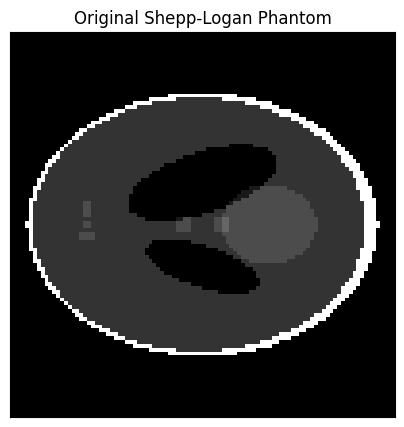

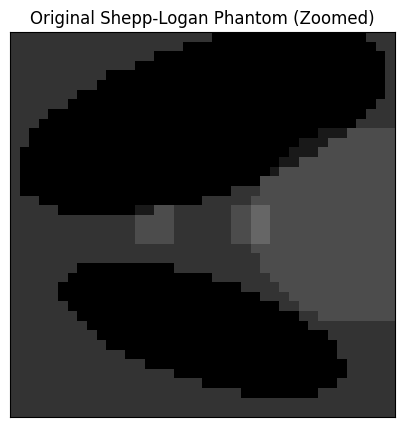

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Original Shepp-Logan Phantom (Zoomed)'}>)

In [64]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)

plot_img(img=phantom, title="Original Shepp-Logan Phantom")
plot_img_zoom(img=phantom, title="Original Shepp-Logan Phantom (Zoomed)")

### For the Nodal-->Modal approach


Since the image space is $100\times 100$, we require the relationships
$$
    \mathrm{DOF}_x = K_x(p+1), \quad \mathrm{DOF}_y = K_y(p+1)
$$
to hold. Where $(\mathrm{DOF}_x, \mathrm{DOF}_y) = (100,100)$, $K_j$ for $j\in \{x,y\}$ denotes the number of elements in the $x-$ and $y-$ directions, and $p$ is the polynomial degree of the modal basis. 

Since $100$ has the prime factorization
$$
    100 = 2^2 \cdot 5^2
$$


the constraint above restricts the possible element-degree pairs $(K,p)$.Some admissible combinations are
1. $(K,p) = (100,0)$
2. $(K,p) = (50,1)$
3. $(K,p) = (25,3)$
4. $(K,p) = (20,4)$
5. $(K,p) = (10,9)$

and others obtained from the divisors of $100$. 

In practice, we only consider the first few cases. The last case is not well suited, since such high polynomial degrees are unnecessary for the present problem and would lead to very large elements.

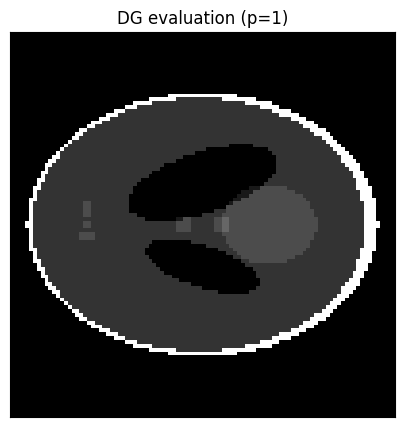

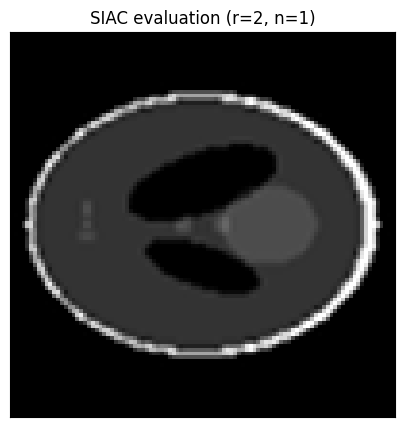

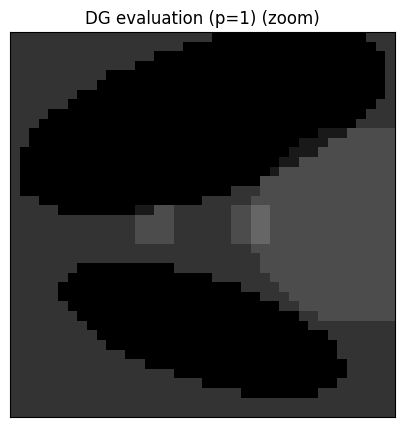

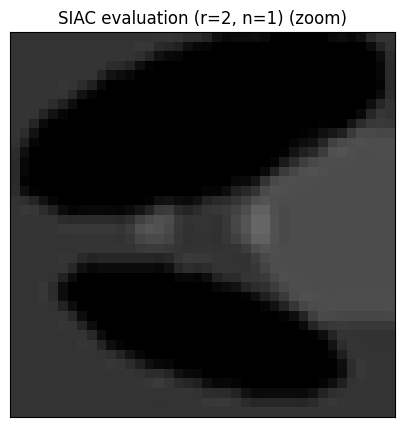

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'SIAC evaluation (r=2, n=1) (zoom)'}>)

In [65]:
#### Testing on the noiseless phantom ####
xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

xlim = (xmin, xmax)
ylim = (ymin, ymax)

# Admissible degrees: 0, 1, 3, 4, 9 (if wrong, will be internally fixed by nodal_image_to_dg
p = 1
order = p + 1

# Postprocessor
moments = 2*p
BSorder = 1

# nodal interpretation: nodal --> modal transform
dg = nodal_image_to_dg(recon=phantom, xlim=xlim, ylim=ylim, p=p)

# immediate evaluation
U_noiseless = eval_dg_on_img_grid(dg=dg)

# Postprocessor
Ustar_noiseless = apply_siac_modal_dg_2d(dg=dg, moments=moments, BSorder=BSorder)

plot_img(img=U_noiseless, title=f"DG evaluation (p={p})")
plot_img(img=Ustar_noiseless, title=f"SIAC evaluation (r={moments}, n={BSorder})")

plot_img_zoom(img=U_noiseless, title=f"DG evaluation (p={p}) (zoom)")
plot_img_zoom(img=Ustar_noiseless, title=f"SIAC evaluation (r={moments}, n={BSorder}) (zoom)")

In [66]:
### Create a Noisy phantom using the FBP ###
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)
### Create the Hann windowed FBP ###
fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")

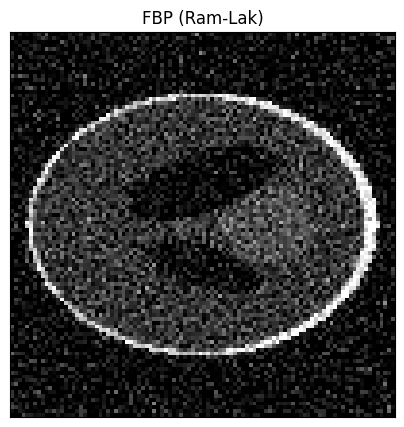

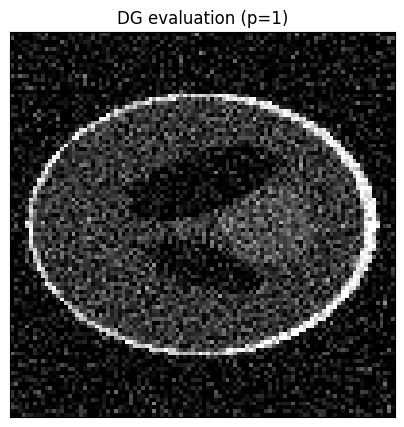

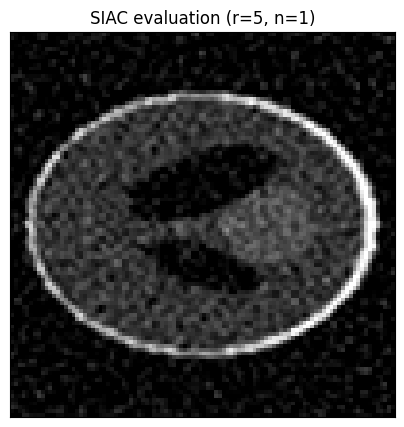

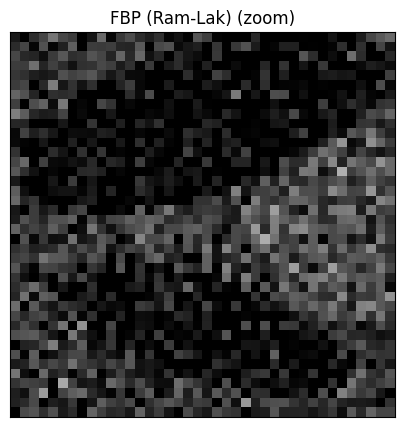

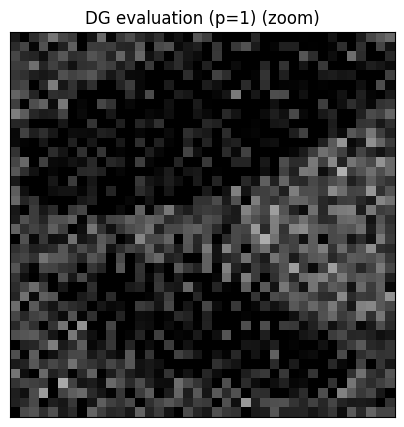

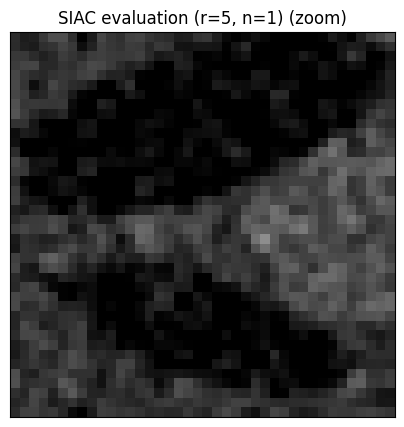

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'SIAC evaluation (r=5, n=1) (zoom)'}>)

In [67]:


# Admissible degrees: 0, 1, 3, 4, 9 (if wrong, will be internally fixed by nodal_image_to_dg
p = 1
order = p + 1

# Postprocessor
moments = 4
BSorder = 1

# nodal interpretation: nodal --> modal transform
dg = nodal_image_to_dg(recon=fbp_ramp, xlim=xlim, ylim=ylim, p=p)

# immediate evaluation
U = eval_dg_on_img_grid(dg=dg)

# Postprocessor
Ustar = apply_siac_modal_dg_2d(dg=dg, moments=moments, BSorder=BSorder)
plot_img(img=fbp_ramp, title=f"FBP ({filter_used})")
plot_img(img=U, title=f"DG evaluation (p={p})")
plot_img(img=Ustar, title=f"SIAC evaluation (r={moments+1}, n={BSorder})")

plot_img_zoom(img=fbp_ramp, title=f"FBP ({filter_used}) (zoom)")
plot_img_zoom(img=U, title=f"DG evaluation (p={p}) (zoom)")
plot_img_zoom(img=Ustar, title=f"SIAC evaluation (r={moments+1}, n={BSorder}) (zoom)")

### Comparison with the Hann filter

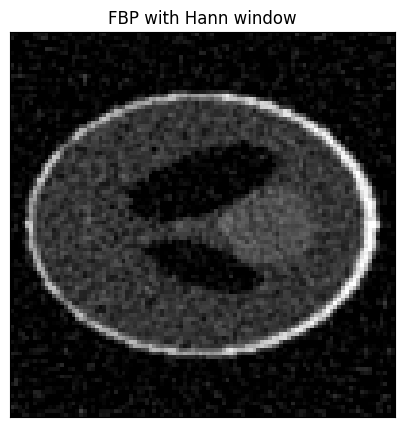

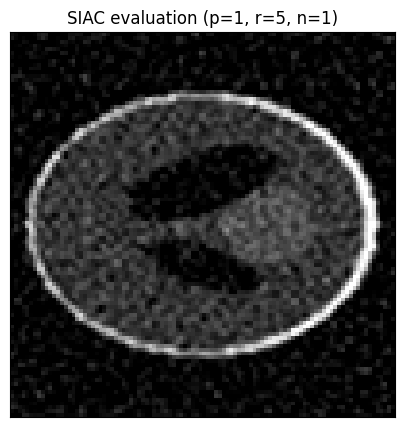

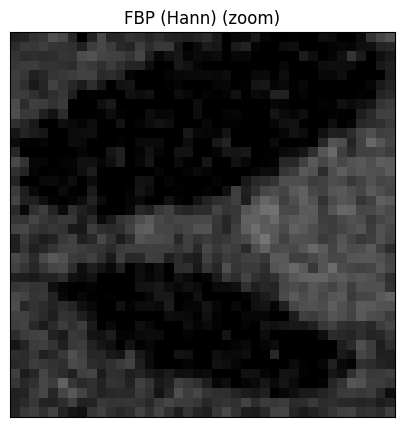

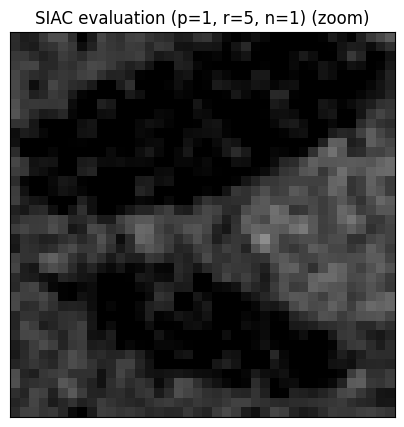

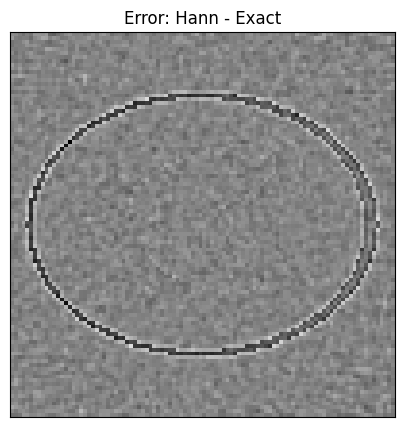

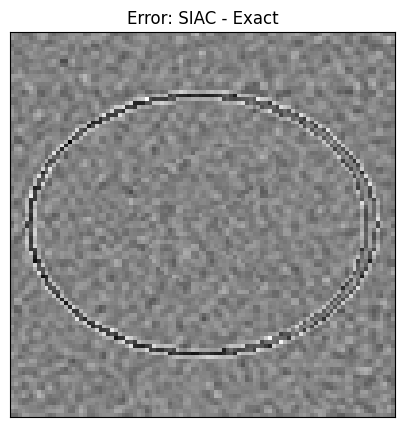

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Error: SIAC - Exact'}>)

In [68]:

plot_img(img=fbp_hann, title="FBP with Hann window")
plot_img(img=Ustar, title=f"SIAC evaluation (p={p}, r={moments+1}, n={BSorder})")

plot_img_zoom(img=fbp_hann, title=f"FBP (Hann) (zoom)")
plot_img_zoom(img=Ustar, title=f"SIAC evaluation (p={p}, r={moments+1}, n={BSorder}) (zoom)")

err_hann = fbp_hann.asarray() - phantom_np
err_siac = Ustar - phantom_np

vmin = min(err_hann.min(), err_siac.min())
vmax = max(err_hann.max(), err_siac.max())
plot_img(img=err_hann, title="Error: Hann - Exact", vmin=vmin, vmax=vmax)
plot_img(img=err_siac, title="Error: SIAC - Exact", vmin=vmin, vmax=vmax)

In [69]:
cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
    },
    "SIAC(FBP-ramp)": {
        "image": Ustar,
        "reference": fbp_ramp.asarray(),
    },
}
dx, dy = space.cell_sides


df = build_metrics_table(
    cases,
    truth=phantom_np,
    dx=dx,
    dy=dy,
    hf_frac=0.6,
    data_range=1.0,
    compute_reference_metrics=False
)

df

,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error
0,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095
1,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476
2,SIAC(FBP-ramp),0.424223,0.386567,0.813330,0.375000,0.708034


### Testing more SIAC parameters

In [70]:
ps = [0, 1, 3]
moments = [2, 4, 6]
BSorders = [1, 2, 3, 4, 5, 6]

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "ramp"},
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "hann"},
    },
}

for p in ps:
    dg = nodal_image_to_dg(recon=fbp_ramp, xlim=xlim, ylim=ylim, p=p)

    for r in moments:
        # admissible SIAC reproduction for DG degree p
        if r > 2*p:
            continue
        for n in BSorders:

            Ustar = apply_siac_modal_dg_2d(dg=dg, moments=r, BSorder=n)

            name = f"DG-SIAC p{p} r{r+1} n{n}"

            cases[name] = {
                "image": Ustar,
                "reference": fbp_ramp.asarray(),
                "extra": {
                    "method": "DG-SIAC",
                    "filter": "ramp",
                    "p": p,
                    "moments": r+1,
                    "BSorder": n,
                },
            }
            
            
            
df = build_metrics_table(
    cases,
    truth=phantom_np,
    dx=dx,
    dy=dy,
    hf_frac=0.6,
    data_range=1.0,
    compute_reference_metrics=False
)

df = build_metrics_table(cases, truth=phantom_np, dx=dx, dy=dy, compute_reference_metrics=False)

df


,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error,method,filter,p,moments,BSorder
0,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095,FBP,ramp,NaN,NaN,NaN
1,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476,FBP,hann,NaN,NaN,NaN
2,DG-SIAC p1 r3 n1,0.419651,0.395792,0.809750,0.375725,0.696194,DG-SIAC,ramp,1.0,3.0,1.0
3,DG-SIAC p1 r3 n2,0.414464,0.439627,0.791804,0.387580,0.677425,DG-SIAC,ramp,1.0,3.0,2.0
4,DG-SIAC p1 r3 n3,0.427724,0.472308,0.762787,0.409999,0.700643,DG-SIAC,ramp,1.0,3.0,3.0
5,DG-SIAC p1 r3 n4,0.440492,0.497047,0.737958,0.427534,0.725204,DG-SIAC,ramp,1.0,3.0,4.0
6,DG-SIAC p1 r3 n5,0.453200,0.516118,0.714346,0.443198,0.749154,DG-SIAC,ramp,1.0,3.0,5.0
7,DG-SIAC p1 r3 n6,0.464894,0.531032,0.692502,0.456812,0.770367,DG-SIAC,ramp,1.0,3.0,6.0
8,DG-SIAC p3 r3 n1,0.519824,0.441427,0.609129,0.508316,0.852326,DG-SIAC,ramp,3.0,3.0,1.0
9,DG-SIAC p3 r3 n2,0.526776,0.538917,0.568917,0.521183,0.865154,DG-SIAC,ramp,3.0,3.0,2.0


In [71]:

# best_by_method = (
#     df.sort_values("truth_rel_l2_err")
#       .groupby("method", as_index=False)
#       .first()
# )

df_dg = df[df["method"] == "DG-SIAC"].copy()

best_l2_row = df_dg.loc[df_dg["rel_l2_err"].idxmin()]
best_masked_l2_row = df_dg.loc[df_dg["masked_rel_l2_err"].idxmin()]
best_gwssim_row = df_dg.loc[df_dg["gw_ssim"].idxmax()]
best_ssim_row = df_dg.loc[df_dg["ssim"].idxmax()]

summary_rows = []

# Baselines
summary_rows.append(df.loc[df["name"] == "FBP-ramp"].iloc[0])
summary_rows.append(df.loc[df["name"] == "FBP-Hann"].iloc[0])

# Best DG-SIAC rows
summary_rows.append(best_l2_row)
summary_rows.append(best_masked_l2_row)
summary_rows.append(best_gwssim_row)
summary_rows.append(best_ssim_row)

df_summary = pd.DataFrame(summary_rows).copy()

df_summary["selected_as"] = [
    "baseline",
    "baseline",
    "best SIAC rel_l2",
    "best SIAC masked_rel_l2",
    "best SIAC gw_ssim",
    "best SIAC ssim",
]

cols = ["selected_as"] + [c for c in df_summary.columns if c != "selected_as"]
df_summary = df_summary[cols]

df_summary

,selected_as,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error,method,filter,p,moments,BSorder
0,baseline,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095,FBP,ramp,NaN,NaN,NaN
1,baseline,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476,FBP,hann,NaN,NaN,NaN
3,best SIAC rel_l2,DG-SIAC p1 r3 n2,0.414464,0.439627,0.791804,0.387580,0.677425,DG-SIAC,ramp,1.0,3.0,2.0
2,best SIAC masked_rel_l2,DG-SIAC p1 r3 n1,0.419651,0.395792,0.809750,0.375725,0.696194,DG-SIAC,ramp,1.0,3.0,1.0
2,best SIAC gw_ssim,DG-SIAC p1 r3 n1,0.419651,0.395792,0.809750,0.375725,0.696194,DG-SIAC,ramp,1.0,3.0,1.0
11,best SIAC ssim,DG-SIAC p3 r3 n4,0.571860,0.545597,0.462830,0.565358,0.917013,DG-SIAC,ramp,3.0,3.0,4.0


From this table, and the consequent plots below, we can conclude that a low polynomial degree, combined with a low moment conservation and low smoothness seems best.

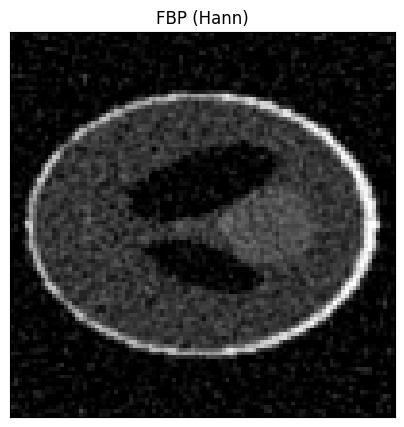

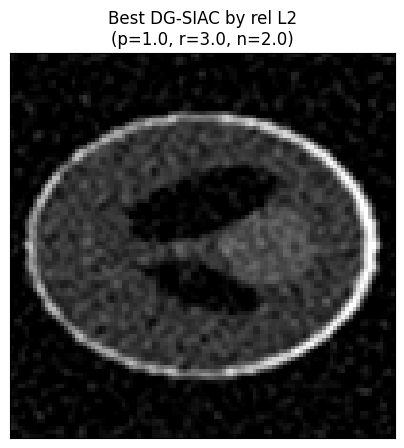

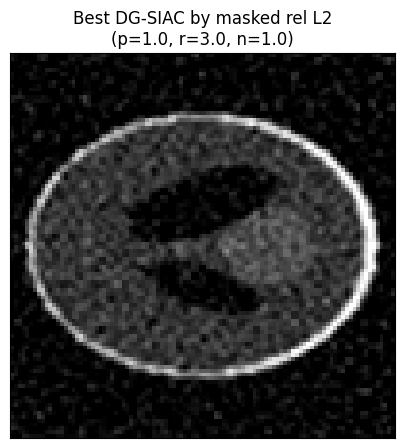

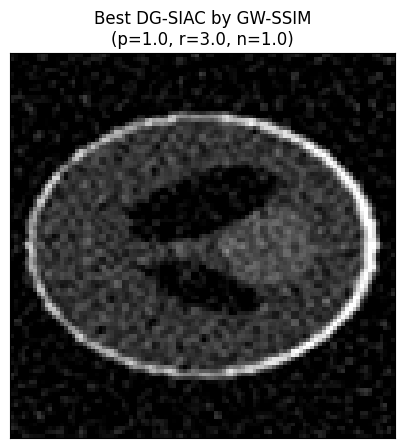

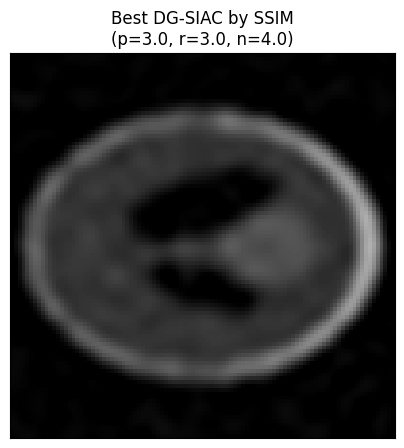

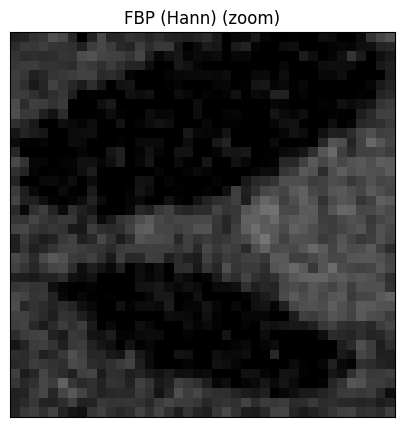

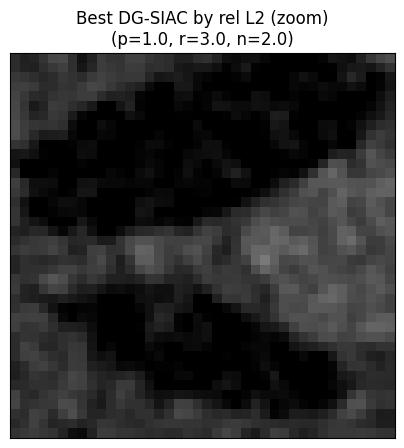

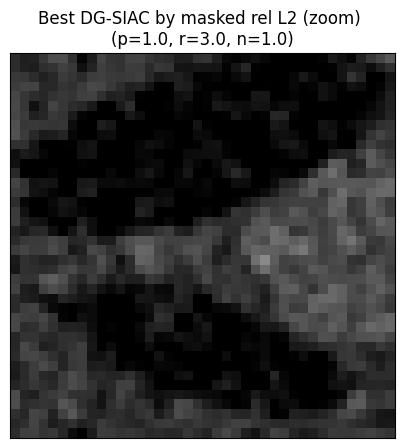

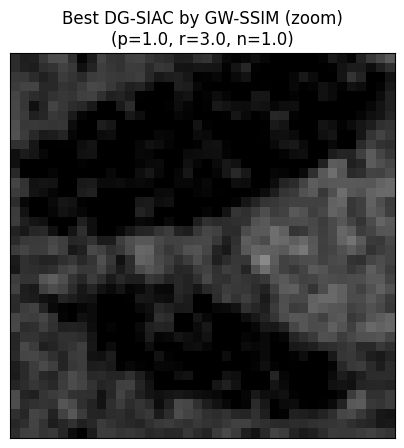

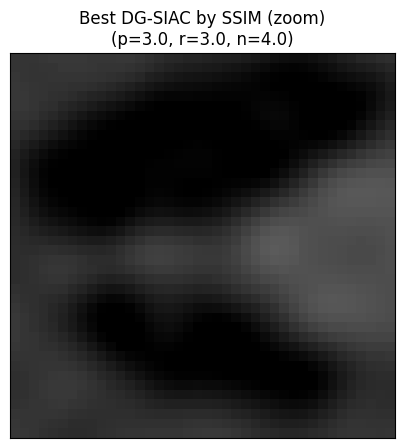

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Best DG-SIAC by SSIM (zoom)\n(p=3.0, r=3.0, n=4.0)'}>)

In [72]:
best_l2_name = best_l2_row["name"]
best_masked_l2_name = best_masked_l2_row["name"]
best_gwssim_name = best_gwssim_row["name"]
best_ssim_name = best_ssim_row["name"]

img_best_l2 = cases[best_l2_name]["image"]
img_best_masked_l2 = cases[best_masked_l2_name]["image"]
img_best_gwssim = cases[best_gwssim_name]["image"]
img_best_ssim = cases[best_ssim_name]["image"]

plot_img(img=fbp_hann, title="FBP (Hann)")
plot_img(
    img=img_best_l2,
    title=f"Best DG-SIAC by rel L2\n(p={best_l2_row['p']}, r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img(
    img=img_best_masked_l2,
    title=f"Best DG-SIAC by masked rel L2\n(p={best_masked_l2_row['p']}, r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img(
    img=img_best_gwssim,
    title=f"Best DG-SIAC by GW-SSIM\n(p={best_gwssim_row['p']}, r={best_gwssim_row['moments']}, n={best_gwssim_row['BSorder']})"
)
plot_img(
    img=img_best_ssim,
    title=f"Best DG-SIAC by SSIM\n(p={best_ssim_row['p']}, r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

plot_img_zoom(img=fbp_hann, title="FBP (Hann) (zoom)")
plot_img_zoom(
    img=img_best_l2,
    title=f"Best DG-SIAC by rel L2 (zoom)\n(p={best_l2_row['p']}, r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_masked_l2,
    title=f"Best DG-SIAC by masked rel L2 (zoom) \n(p={best_masked_l2_row['p']}, r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)

plot_img_zoom(
    img=img_best_gwssim,
    title=f"Best DG-SIAC by GW-SSIM (zoom)\n(p={best_gwssim_row['p']}, r={best_gwssim_row['moments']}, n={best_gwssim_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_ssim,
    title=f"Best DG-SIAC by SSIM (zoom)\n(p={best_ssim_row['p']}, r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

### Plotting the SSIM mapsand Phantom masks for visual

Gradient-weighted SSIM: 0.4615991904371274


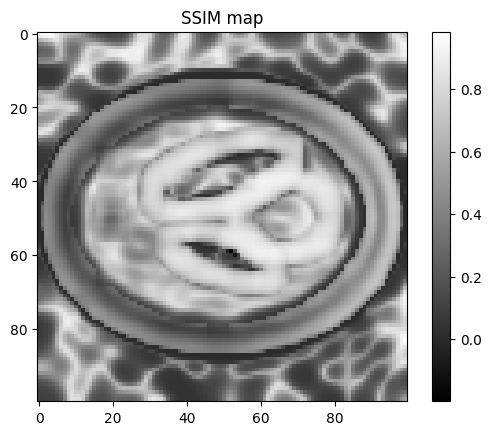

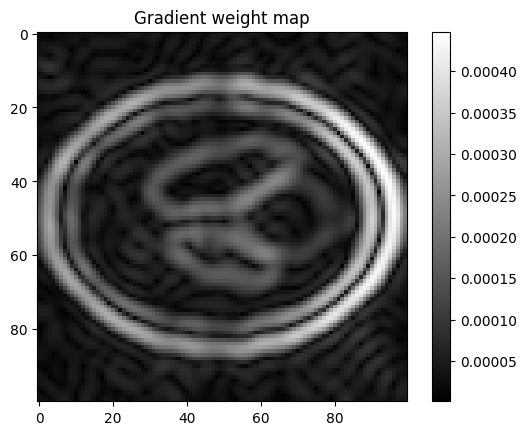

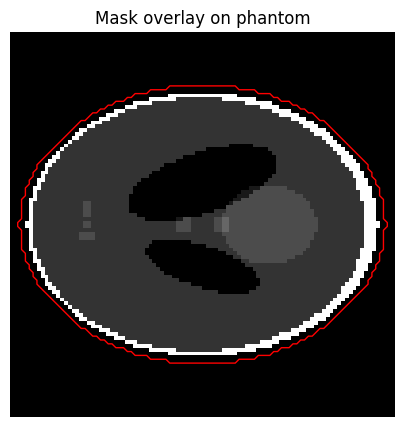

In [73]:
from src.metrics import gradient_weighted_ssim, phantom_support_mask
gw, ssim_map, wmap = gradient_weighted_ssim(
    phantom_np, Ustar, alpha=0.75, sigma=1.0,
    return_maps=True
    )
print("Gradient-weighted SSIM:", gw)

plt.figure()
plt.imshow(ssim_map, cmap="gray")
plt.title("SSIM map")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(wmap, cmap="gray")
plt.title("Gradient weight map")
plt.colorbar()
plt.show()

mask = phantom_support_mask(phantom_np, tau=1e-8, pad_pixels=2)

plt.figure(figsize=(5,5))
plt.imshow(phantom_np, cmap="gray")
plt.contour(mask, colors="red", linewidths=1)
plt.title("Mask overlay on phantom")
plt.axis("off")
plt.show()

### Beyond the Scope: Feeding the DG-SIAC code the Hann windowed FBP

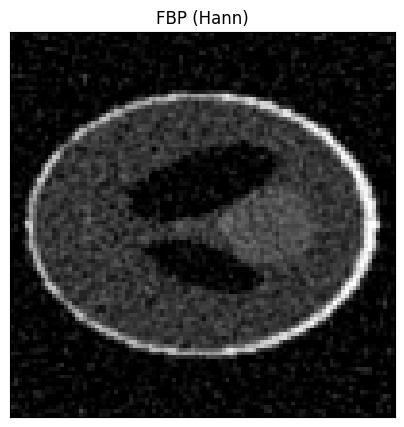

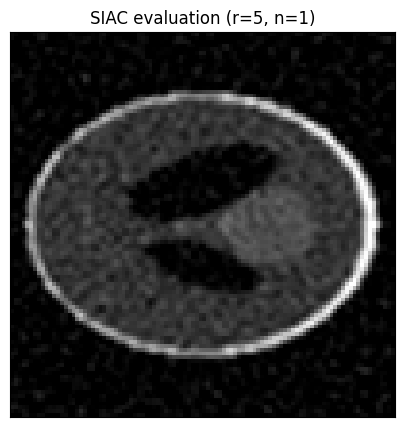

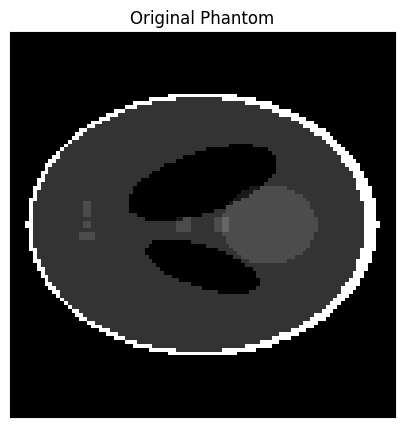

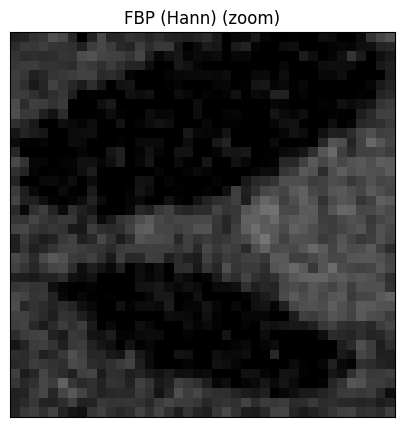

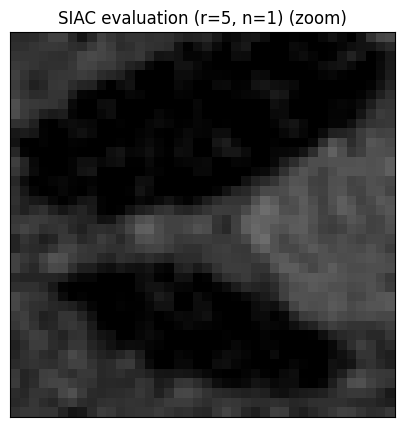

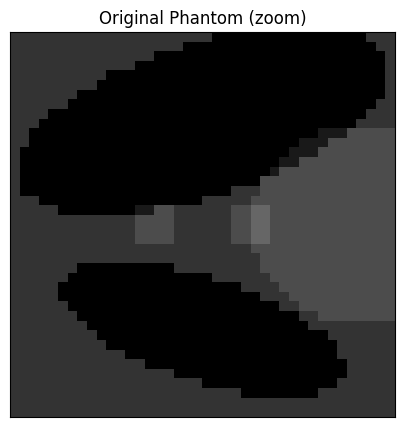

,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error
0,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095
1,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476
2,SIAC(FBP-Hann),0.399689,0.496760,0.796353,0.382974,0.652727


In [90]:


# Admissible degrees: 0, 1, 3, 4, 9 (if wrong, will be internally fixed by nodal_image_to_dg
p = 1
order = p + 1

# Postprocessor
moments = 4
BSorder = 1

# nodal interpretation: nodal --> modal transform
dg = nodal_image_to_dg(recon=fbp_hann, xlim=xlim, ylim=ylim, p=p)

# immediate evaluation
U = eval_dg_on_img_grid(dg=dg)

# Postprocessor
Ustar = apply_siac_modal_dg_2d(dg=dg, moments=moments, BSorder=BSorder)
plot_img(img=fbp_hann, title=f"FBP (Hann)")
# plot_img(img=U, title=f"DG evaluation (p={p})")
plot_img(img=Ustar, title=f"SIAC evaluation (r={moments+1}, n={BSorder})")
plot_img(img=phantom, title="Original Phantom")

plot_img_zoom(img=fbp_hann, title=f"FBP (Hann) (zoom)")
# plot_img_zoom(img=U, title=f"DG evaluation (p={p}) (zoom)")
plot_img_zoom(img=Ustar, title=f"SIAC evaluation (r={moments+1}, n={BSorder}) (zoom)")
plot_img_zoom(img=phantom, title="Original Phantom (zoom)")

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
    },
    "SIAC(FBP-Hann)": {
        "image": Ustar,
        "reference": fbp_ramp.asarray(),
    },
}
dx, dy = space.cell_sides


df = build_metrics_table(
    cases,
    truth=phantom_np,
    dx=dx,
    dy=dy,
    hf_frac=0.6,
    data_range=1.0,
    compute_reference_metrics=False
)

df